# 03-Structured Output & Pydantic Coercion

In Lesson 02, we bridged the Air Gap between the generative neural network and the deterministic Python server using Function Calling. We allowed the LLM to trigger physical Python tools.

However, Function Calling is an *action-oriented* architecture. What if our goal isn't to trigger an external API, but rather to **extract complex, deeply nested data** from unstructured text? What if we need the Agent to synthesize a strict mathematical state object to pass into our local database or down the LangGraph pipeline?

If we rely on prompt engineering alone (*"Please output valid JSON..."*), the LLM will eventually hallucinate a missing comma, append conversational filler (*"Here is your JSON:"*), or return a string instead of an integer. This instantly destroys downstream pipelines.

To mathematically guarantee the structural integrity of our Agent's thoughts, we must enforce **Structured Outputs via Pydantic Coercion**.

Let's set up our environment to engineer strict memory schemas.

In [4]:
# Required installations: pip install langchain langchain-core langchain-ollama pydantic matplotlib seaborn
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Pydantic Coercion Environment Ready.")

✅ Systems Architecture & Pydantic Coercion Environment Ready.


# 1. The Mathematics of Type Coercion

An LLM's autoregressive generation operates over a near-infinite space of text strings, which we define as $\Sigma^*$.
When building an Enterprise application, we do not want infinite possibilities. We want our output to belong to a strictly bounded, finite subset of valid JSON objects, which we define as $\mathcal{V}$.

If we rely purely on the LLM's raw policy $\pi_\theta$, the probability of generating a perfectly valid object $v \in \mathcal{V}$ decays exponentially as the complexity of the schema increases.

To solve this, modern frameworks fuse the LLM's generation loop with **Pydantic**, creating a mathematical mapping function $f_{coerce}$:


$$f_{coerce}: \Sigma^* \rightarrow \mathcal{V} \cup \{\text{Error}\}$$

Pydantic acts as an impenetrable topological boundary. It intercepts the logits generated by the LLM and forces them into a strict Python object.

* If the LLM tries to generate `"risk_score": "nine"`, the structural enforcer physically rejects the string tokens, ensuring the final object yields `9` (an integer).
* LangChain's `.with_structured_output()` wraps this entire physics engine into a single method, guaranteeing that your pipeline receives a programmatic object, not a block of text.

# 2. Architecting the Extraction Schema

Let's build an Enterprise data extraction pipeline. We will define a strict Pydantic schema for parsing financial risk assessments, feed a highly unstructured, conversational string to local **Llama 3.2**, and observe the exact physical object that is returned.

In [5]:
# --- 🧱 The Pydantic Coercion Engine ---

# 1. Define the Strict Mathematical Boundary using Pydantic
class RiskAssessment(BaseModel):
    """A strictly typed schema for evaluating corporate risk."""
    company_name: str = Field(..., description="The exact legal entity name.")
    risk_score: int = Field(..., description="Calculated risk score from 1 to 10.")
    is_high_risk: bool = Field(..., description="True if the risk_score is greater than 7.")
    key_factors: list[str] = Field(..., description="A strict array of the exact risk factors mentioned.")

# 2. Initialize the Local Llama 3.2 Model
print("--- 🧠 Initializing Llama 3.2 Structured Output ---")
llm = ChatOllama(model="llama3.2", temperature=0)

# The Magic: We bind the Pydantic schema directly to the model.
# The LLM will now return a `RiskAssessment` object, NOT an AIMessage string.
structured_llm = llm.with_structured_output(RiskAssessment)

# 3. The Unstructured Input (The Chaos)
messy_text_input = """
I just got out of the meeting reviewing CyberDyne Systems LLC. 
Honestly, they are looking incredibly dangerous right now. I'd have to give them 
a solid 9 out of 10 on our danger scale. The main issues are an unstable power core, 
a rogue AI module, and absolutely terrible PR. Seriously, avoid investing.
"""

print(f"Raw Input String:\n'{messy_text_input.strip()}'\n")

# 4. The Structured Forward Pass (The Order)
print("--- 🛡️ Executing Pydantic Coercion Pipeline ---")
# We invoke the LLM. It processes the text, maps it to the schema, and returns the object.
extracted_data = structured_llm.invoke(messy_text_input)

# 5. Verify the Physical Object Types
print(f"✅ SUCCESS: Pydantic coerced the chaos into a strict Python Object!")
print(f"Object Type: {type(extracted_data)}\n")

print("--- 📊 Inspecting the Extracted Variables ---")
print(f"Company Name : {extracted_data.company_name} (Type: {type(extracted_data.company_name).__name__})")
print(f"Risk Score   : {extracted_data.risk_score} (Type: {type(extracted_data.risk_score).__name__})")
print(f"Is High Risk : {extracted_data.is_high_risk} (Type: {type(extracted_data.is_high_risk).__name__})")
print(f"Key Factors  : {extracted_data.key_factors} (Type: {type(extracted_data.key_factors).__name__})")

print("\n--- 💡 Engineering Insight ---")
print("Look closely at the output types! The LLM didn't return a string of JSON. It returned an instantiated Python `RiskAssessment` class. You can now immediately use `extracted_data.risk_score > 5` in your backend code without parsing, stripping markdown blockticks (```json), or worrying about `JSONDecodeError`s. The structural integrity of the pipeline is mathematically guaranteed.")

--- 🧠 Initializing Llama 3.2 Structured Output ---
Raw Input String:
'I just got out of the meeting reviewing CyberDyne Systems LLC. 
Honestly, they are looking incredibly dangerous right now. I'd have to give them 
a solid 9 out of 10 on our danger scale. The main issues are an unstable power core, 
a rogue AI module, and absolutely terrible PR. Seriously, avoid investing.'

--- 🛡️ Executing Pydantic Coercion Pipeline ---
✅ SUCCESS: Pydantic coerced the chaos into a strict Python Object!
Object Type: <class '__main__.RiskAssessment'>

--- 📊 Inspecting the Extracted Variables ---
Company Name : CyberDyne Systems LLC (Type: str)
Risk Score   : 9 (Type: int)
Is High Risk : True (Type: bool)
Key Factors  : ['unstable power core', 'rogue AI module', 'terrible PR'] (Type: list)

--- 💡 Engineering Insight ---
Look closely at the output types! The LLM didn't return a string of JSON. It returned an instantiated Python `RiskAssessment` class. You can now immediately use `extracted_data.risk_sco

# 3. Visualizing Probability Space Collapse

To understand why this is physically necessary for multi-agent workflows, we must visualize the collapse of the LLM's probability space.

An unconstrained LLM generates points across a vast, chaotic, conversational dimension. Pydantic acts as a **Geometric Manifold**, forcing the outputs to snap into a rigid, structured programmatic grid.

/tmp/ipykernel_13172/398084459.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  pydantic_box = patches.Rectangle((7.5, 2.5), 5, 5, fill=True, color='#2ecc71', alpha=0.1, linewidth=3, edgecolor='#27ae60')


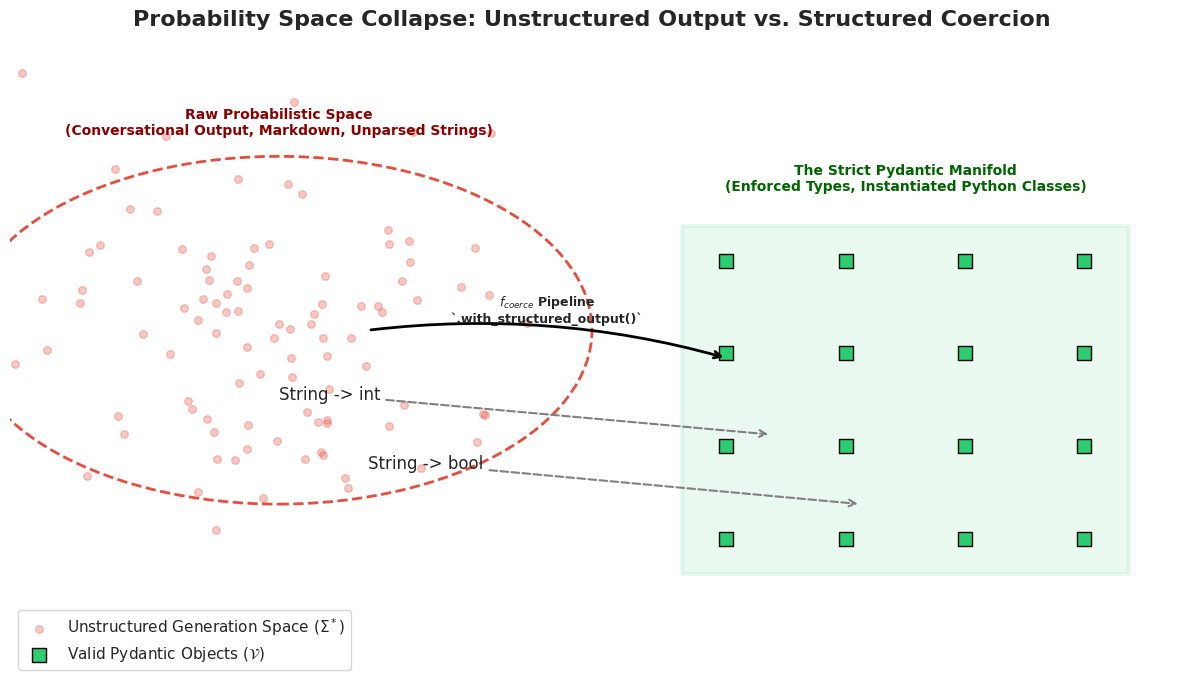

In [6]:
# Visualizing the Pydantic Topology
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Probability Space Collapse: Unstructured Output vs. Structured Coercion", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. The Unstructured LLM Space (Chaos)
np.random.seed(42)
chaos_x = np.random.normal(3, 1.5, 100)
chaos_y = np.random.normal(6, 1.5, 100)
ax.scatter(chaos_x, chaos_y, color='#e74c3c', alpha=0.3, s=30, label="Unstructured Generation Space ($\\Sigma^*$)")

# Draw the chaos boundary
chaos_circle = patches.Ellipse((3, 6), 7, 5, angle=0, fill=False, color='#e74c3c', linestyle='--', linewidth=2)
ax.add_patch(chaos_circle)
ax.text(3, 8.8, "Raw Probabilistic Space\n(Conversational Output, Markdown, Unparsed Strings)", 
        ha='center', color='darkred', fontweight='bold', fontsize=10)

# 2. The Pydantic Structured Manifold (Order)
grid_x, grid_y = np.meshgrid(np.linspace(8, 12, 4), np.linspace(3, 7, 4))
ax.scatter(grid_x, grid_y, color='#2ecc71', s=100, marker='s', edgecolors='black', zorder=3, label="Valid Pydantic Objects ($\\mathcal{V}$)")

# Draw the strict boundary
pydantic_box = patches.Rectangle((7.5, 2.5), 5, 5, fill=True, color='#2ecc71', alpha=0.1, linewidth=3, edgecolor='#27ae60')
ax.add_patch(pydantic_box)
ax.text(10, 8, "The Strict Pydantic Manifold\n(Enforced Types, Instantiated Python Classes)", 
        ha='center', color='darkgreen', fontweight='bold', fontsize=10)

# 3. The Coercion Arrows (The Physics of f_coerce)
# Successful Coercion (Snapping to the grid)
ax.annotate("", xy=(8, 5.6), xytext=(4, 6), arrowprops=dict(arrowstyle="->", color="black", lw=2, connectionstyle="arc3,rad=-0.1"))
ax.text(6, 6.1, "$f_{coerce}$ Pipeline\n`.with_structured_output()`", ha='center', fontsize=9, fontweight='bold', rotation=0)

# Highlighting specific mappings
ax.annotate("String -> int", xy=(8.5, 4.5), xytext=(3, 5), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, linestyle="--"))
ax.annotate("String -> bool", xy=(9.5, 3.5), xytext=(4, 4), arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, linestyle="--"))

plt.xlim(0, 13)
plt.ylim(1, 10)
ax.legend(loc="lower left", fontsize=11)

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of the difference between standard LLM prompts and Pydantic Coercion like **Submitting a Customs Declaration at the Airport**:

* **Unstructured Output (The Blank Piece of Paper)**: You hand the traveler (the LLM) a blank piece of paper and say, *"Please write down everything you are bringing into the country, the exact monetary value of the goods, and whether you are carrying agricultural products."* The traveler writes a conversational essay about their vacation: *"I bought a cool watch for a few hundred bucks."* They completely forget to mention agricultural products. The digital customs scanner cannot parse this. The system halts.
* **Pydantic Coercion (The Strict Customs Form)**: You hand the traveler a rigid, structured digital form with three exact database fields.
* Field 1: `[Item Name - str]`
* Field 2: `[Value - float]`
* Field 3: `[Carrying Agriculture? - bool]`.
* If the traveler tries to input "a few hundred bucks" into Field 2, the system physically blocks them and forces them to input `300.0`. The downstream customs officers receive perfectly formatted, mathematically sound data every single time.